<a href="https://colab.research.google.com/github/MichalWeisman/Interpretable-ViT-for-Timeseries/blob/master/notebooks/colab_mimic_hypotension_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIMIC-IV Hypotension ViT POC

This notebook converts prepared `records.csv` and `labels.csv` files into tensors, trains a small ViT for a few epochs, evaluates it, generates explanations, clusters them, and plots aggregate explanation heatmaps.

Expected input format:
- `records.csv`: `patient_id`, `variable`, `value`, `timestamp`
- `labels.csv`: `patient_id`, `label`

The notebook is designed for Google Colab with the project uploaded to Google Drive.

## 1. Mount Drive And Choose Paths

Edit `PROJECT_DIR` and `DATA_DIR` if your Drive paths are different.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
import os

# Change these if your folders have different names in Drive.
PROJECT_DIR = Path('/content/drive/MyDrive/Interpretable-ViT-for-Timeseries')
DATA_DIR = PROJECT_DIR / 'data' / 'mimic_hypotension'

RECORDS_PATH = DATA_DIR / 'records.csv'
LABELS_PATH = DATA_DIR / 'labels.csv'

print('PROJECT_DIR:', PROJECT_DIR)
print('RECORDS_PATH exists:', RECORDS_PATH.exists(), RECORDS_PATH)
print('LABELS_PATH exists:', LABELS_PATH.exists(), LABELS_PATH)

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f'PROJECT_DIR does not exist: {PROJECT_DIR}')
if not RECORDS_PATH.exists() or not LABELS_PATH.exists():
    raise FileNotFoundError('records.csv and labels.csv must exist under DATA_DIR.')

PROJECT_DIR: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries
RECORDS_PATH exists: True /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/data/mimic_hypotension/records.csv
LABELS_PATH exists: True /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/data/mimic_hypotension/labels.csv


## 2. Install The Project And Check GPU

In [3]:
import subprocess
import sys

os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())

# Colab already includes torch in most runtimes. This installs the package plus any missing dependencies.
!pip -q install -e .
!pip -q install -r requirements.txt

try:
    print(subprocess.check_output(['nvidia-smi'], text=True))
except Exception as exc:
    print('No GPU visible to nvidia-smi:', repr(exc))

import torch
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')

Working directory: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for interpretable-ts-vit (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 27.8 MB/s eta 0:00:00
Thu Jul  2 14:42:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |     

## 3. Create A Small Balanced POC Dataset

This keeps the Colab run short. Set `USE_SUBSET = False` to use all prepared rows.

In [4]:
import pandas as pd

USE_SUBSET = True
PATIENTS_PER_CLASS = 120
RANDOM_STATE = 13

POC_DATA_DIR = PROJECT_DIR / 'data' / 'mimic_hypotension_colab_poc'
POC_DATA_DIR.mkdir(parents=True, exist_ok=True)
POC_RECORDS_PATH = POC_DATA_DIR / 'records.csv'
POC_LABELS_PATH = POC_DATA_DIR / 'labels.csv'

if USE_SUBSET:
    labels = pd.read_csv(LABELS_PATH)
    counts = labels['label'].value_counts()
    per_class = min(PATIENTS_PER_CLASS, int(counts.min()))
    sampled_labels = (
        labels.groupby('label', group_keys=False)
        .sample(n=per_class, random_state=RANDOM_STATE)
        .sort_values('patient_id')
    )
    sampled_ids = set(sampled_labels['patient_id'].astype(str))
    sampled_labels.to_csv(POC_LABELS_PATH, index=False)

    first = True
    kept = 0
    for chunk in pd.read_csv(RECORDS_PATH, chunksize=500_000, dtype={'patient_id': str}):
        selected = chunk[chunk['patient_id'].isin(sampled_ids)]
        if len(selected):
            selected.to_csv(POC_RECORDS_PATH, index=False, mode='w' if first else 'a', header=first)
            first = False
            kept += len(selected)
    if first:
        pd.DataFrame(columns=['patient_id', 'variable', 'value', 'timestamp']).to_csv(POC_RECORDS_PATH, index=False)
    print(f'Created POC subset: {len(sampled_labels)} patients, {kept} records')
    active_records_path = POC_RECORDS_PATH
    active_labels_path = POC_LABELS_PATH
else:
    active_records_path = RECORDS_PATH
    active_labels_path = LABELS_PATH

print('Active records:', active_records_path)
print('Active labels:', active_labels_path)
print(pd.read_csv(active_labels_path)['label'].value_counts())

Created POC subset: 240 patients, 8381 records
Active records: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/data/mimic_hypotension_colab_poc/records.csv
Active labels: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/data/mimic_hypotension_colab_poc/labels.csv
label
False    120
True     120
Name: count, dtype: int64


## 4. Configure And Run The Full Pipeline

Artifacts are written under `runs/colab_hypotension_poc` inside the project folder in Drive.

In [6]:
from pathlib import Path
import os, sys

PROJECT_DIR = Path('/content/drive/MyDrive/Interpretable-ViT-for-Timeseries')  # edit if needed
os.chdir(PROJECT_DIR)

print(os.getcwd())
print((PROJECT_DIR / 'src' / 'interpretable_ts_vit').exists())

sys.path.insert(0, str(PROJECT_DIR / 'src'))

!python -m pip install -e .

import interpretable_ts_vit
print("Package import OK:", interpretable_ts_vit)

/content/drive/MyDrive/Interpretable-ViT-for-Timeseries
True
Obtaining file:///content/drive/MyDrive/Interpretable-ViT-for-Timeseries
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for interpretable-ts-vit (pyproject.toml) ... done
  Created wheel for interpretable-ts-vit: filename=interpretable_ts_vit-0.1.0-0.editable-py3-none-any.whl size=4749 sha256=a65b834474c1a67cf308379a22a07772a2072bc2e3e7dd1706d0b28d8e03fcbe
  Stored in directory: /tmp/pip-ephem-wheel-cache-lq0196uf/wheels/c8/8c/b5/52a59fca76921c1667f15dc9e903515f47960d474594399021
Successfully built interpretable-ts-vit
  Attempting uninstall: interpretable-ts-vit
    Found existing installation: interpretable-ts-vit 0.1.0
    Uninstalling interpretable-ts-vit-0.1.0:
      Successfully uninstalled interpretable-ts-vit-0.1.0
Package import OK: <modul

In [7]:
from interpretable_ts_vit.config import Config, DataConfig, ModelConfig, TrainConfig, ExplainConfig, ClusterConfig
from interpretable_ts_vit.pipeline import PipelinePaths, PipelineRunConfig, run_pipeline

RUN_DIR = PROJECT_DIR / 'runs' / 'colab_hypotension_poc'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed_colab_hypotension_poc'

config = Config(
    data=DataConfig(
        granularity='30min',
        aggregation='mean',
        val_fraction=0.2,
        test_fraction=0.2,
        random_state=RANDOM_STATE,
    ),
    model=ModelConfig(
        patch_size=(1, 4),
        embed_dim=48,
        depth=2,
        num_heads=4,
        mlp_ratio=2.0,
        dropout=0.1,
    ),
    train=TrainConfig(
        batch_size=32,
        epochs=3,
        learning_rate=1e-3,
        weight_decay=1e-4,
        device='cuda' if torch.cuda.is_available() else 'cpu',
    ),
    explain=ExplainConfig(method='grad_attention_rollout', target_class=1),
    cluster=ClusterConfig(n_clusters=4, method='kmeans', aggregate='mean'),
)

paths = PipelinePaths(
    records_path=active_records_path,
    labels_path=active_labels_path,
    processed_dir=PROCESSED_DIR,
    run_dir=RUN_DIR,
)

run_config = PipelineRunConfig(
    paths=paths,
    config=config,
    prepare_mimic=False,
    prepare_tensors=True,
    train=True,
    evaluate=True,
    explain=True,
    cluster=True,
    plot=True,
    split='test',
    render_instance_heatmaps=False,
)

result = run_pipeline(run_config)
print('Artifacts:')
for key, value in result.artifacts.items():
    print(f'  {key}: {value}')
print('\nTrain metrics:', result.train_metrics)
print('\nEvaluation metrics:', result.evaluation_metrics)

Artifacts:
  processed_dir: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/data/processed_colab_hypotension_poc
  run_dir: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc
  evaluation_metrics: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc/test_evaluation_metrics.json
  explanations: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc/explanations/test
  clusters: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc/clusters/test
  cluster_heatmaps: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc/cluster_heatmaps/test

Train metrics: {'accuracy': 0.5208333333333334, 'macro_f1': 0.3780281690140845, 'confusion_matrix': [[24, 0], [23, 1]], 'auroc': 0.5234375, 'history': [{'epoch': 1.0, 'train_loss': 0.7768244743347168, 'val_accuracy': 0.5, 'val_macro_f1': 0.3333333333333333, 'val_auroc': 0.6137152777777777}, {'epoch

## 5. Inspect Saved Artifacts And Metrics

In [8]:
import json

print('Run directory:', RUN_DIR)
print('Saved files:')
for path in sorted(RUN_DIR.rglob('*')):
    if path.is_file():
        print(' ', path.relative_to(RUN_DIR))

metrics_path = RUN_DIR / 'test_evaluation_metrics.json'
if metrics_path.exists():
    with metrics_path.open() as fh:
        print('\nEvaluation metrics JSON:')
        print(json.dumps(json.load(fh), indent=2))

predictions_path = RUN_DIR / 'test_predictions.csv'
if predictions_path.exists():
    display(pd.read_csv(predictions_path).head())

Run directory: /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc
Saved files:
  binner.json
  cluster_heatmaps/test/cluster_0.png
  cluster_heatmaps/test/cluster_1.png
  cluster_heatmaps/test/cluster_2.png
  cluster_heatmaps/test/cluster_3.png
  clusters/test/cluster_0.npy
  clusters/test/cluster_1.npy
  clusters/test/cluster_2.npy
  clusters/test/cluster_3.npy
  clusters/test/cluster_assignments.csv
  explanations/test/30085418.npy
  explanations/test/30106663.npy
  explanations/test/30223270.npy
  explanations/test/30348443.npy
  explanations/test/30695838.npy
  explanations/test/31256032.npy
  explanations/test/31301025.npy
  explanations/test/31559011.npy
  explanations/test/31694499.npy
  explanations/test/31801380.npy
  explanations/test/31846222.npy
  explanations/test/31935699.npy
  explanations/test/31971649.npy
  explanations/test/32136714.npy
  explanations/test/32455752.npy
  explanations/test/32491919.npy
  explanations/test/32496248.npy
  

,patient_id,predicted_label,prob_False,prob_True
0,30085418,True,0.479789,0.520211
1,30106663,False,0.548429,0.451571
2,30223270,False,0.555256,0.444744
3,30348443,False,0.546492,0.453508
4,30695838,True,0.484932,0.515068


## 6. Display Cluster Explanation Heatmaps

Found 4 cluster heatmaps in /content/drive/MyDrive/Interpretable-ViT-for-Timeseries/runs/colab_hypotension_poc/cluster_heatmaps/test
cluster_0.png


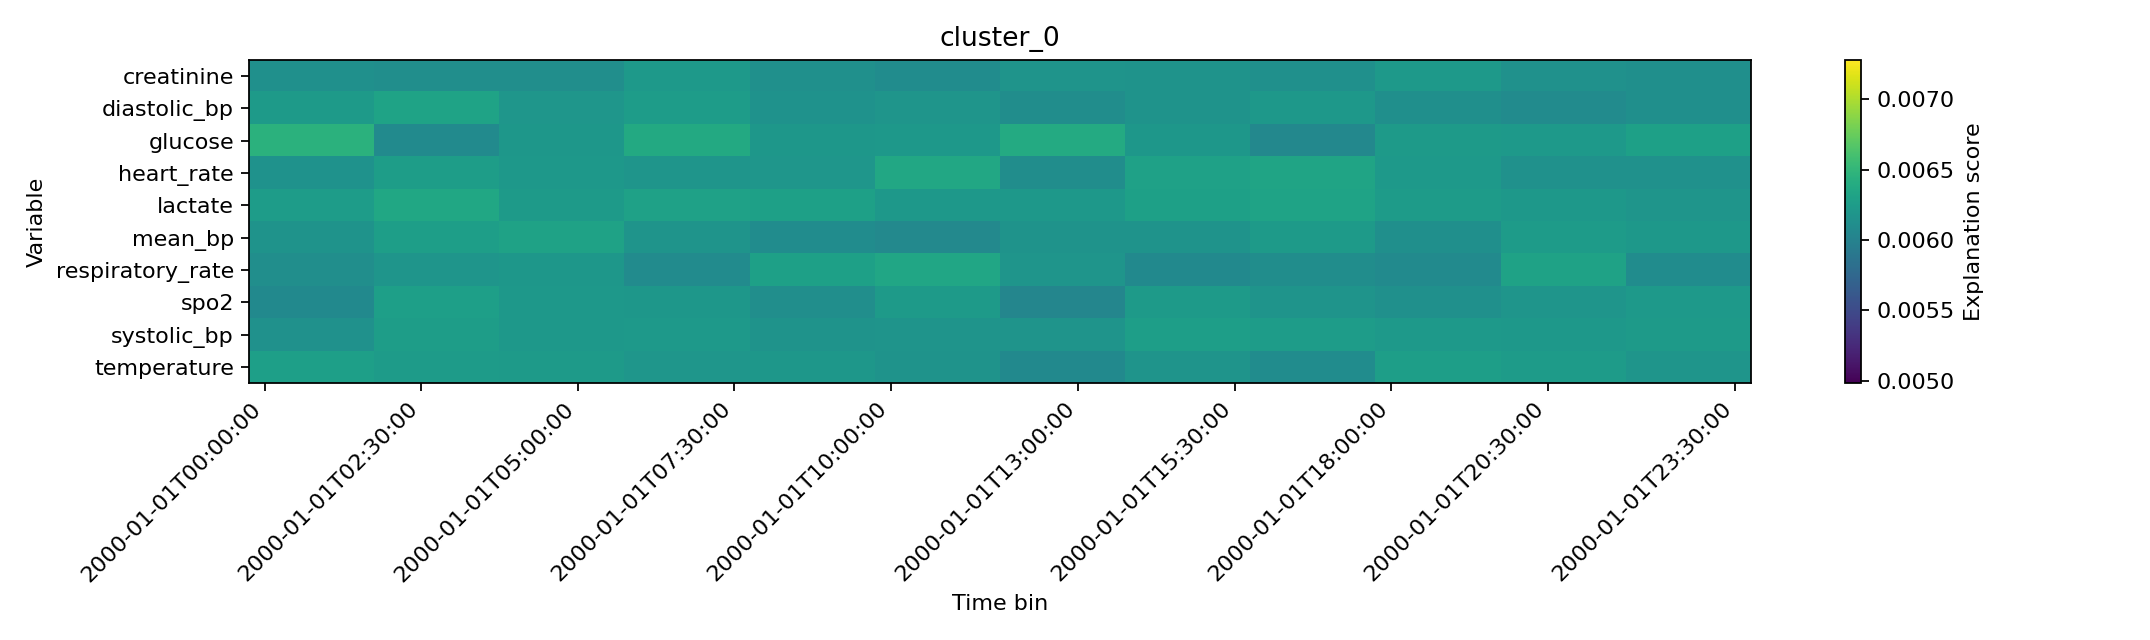

cluster_1.png


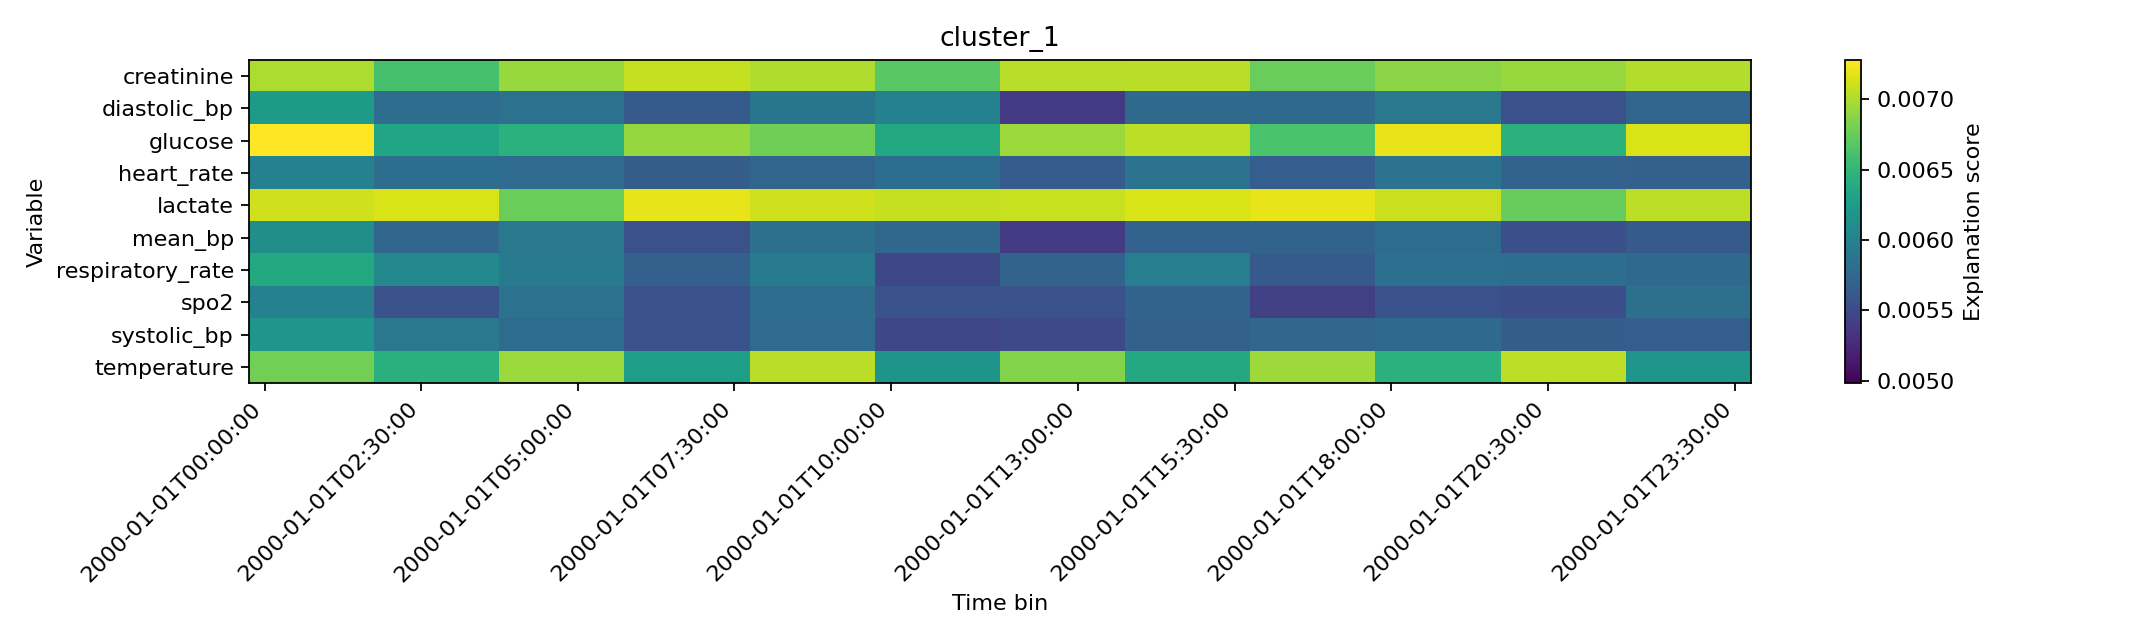

cluster_2.png


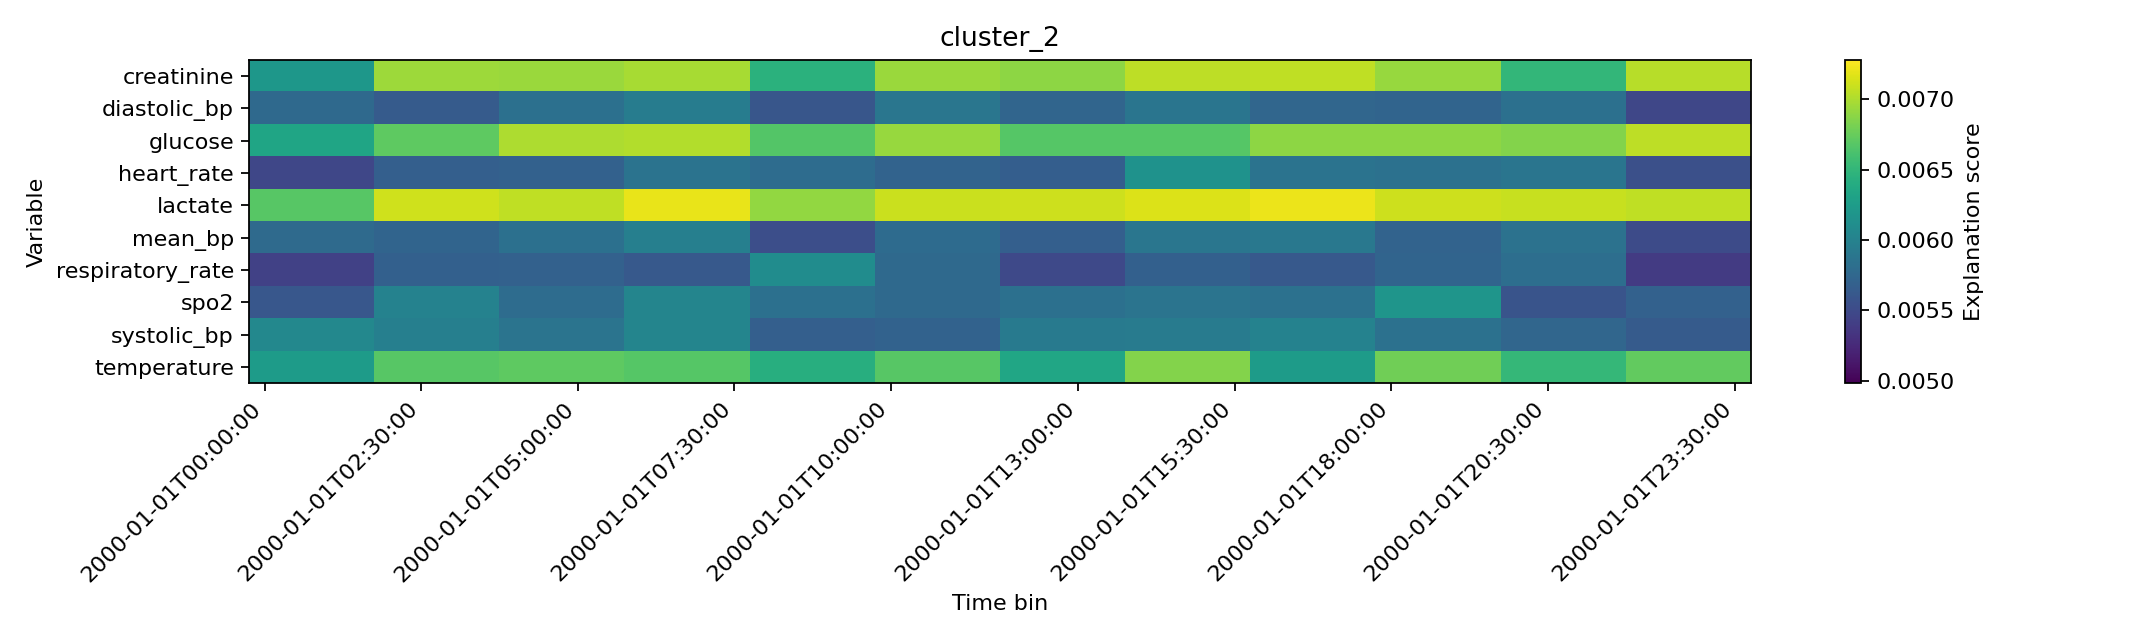

cluster_3.png


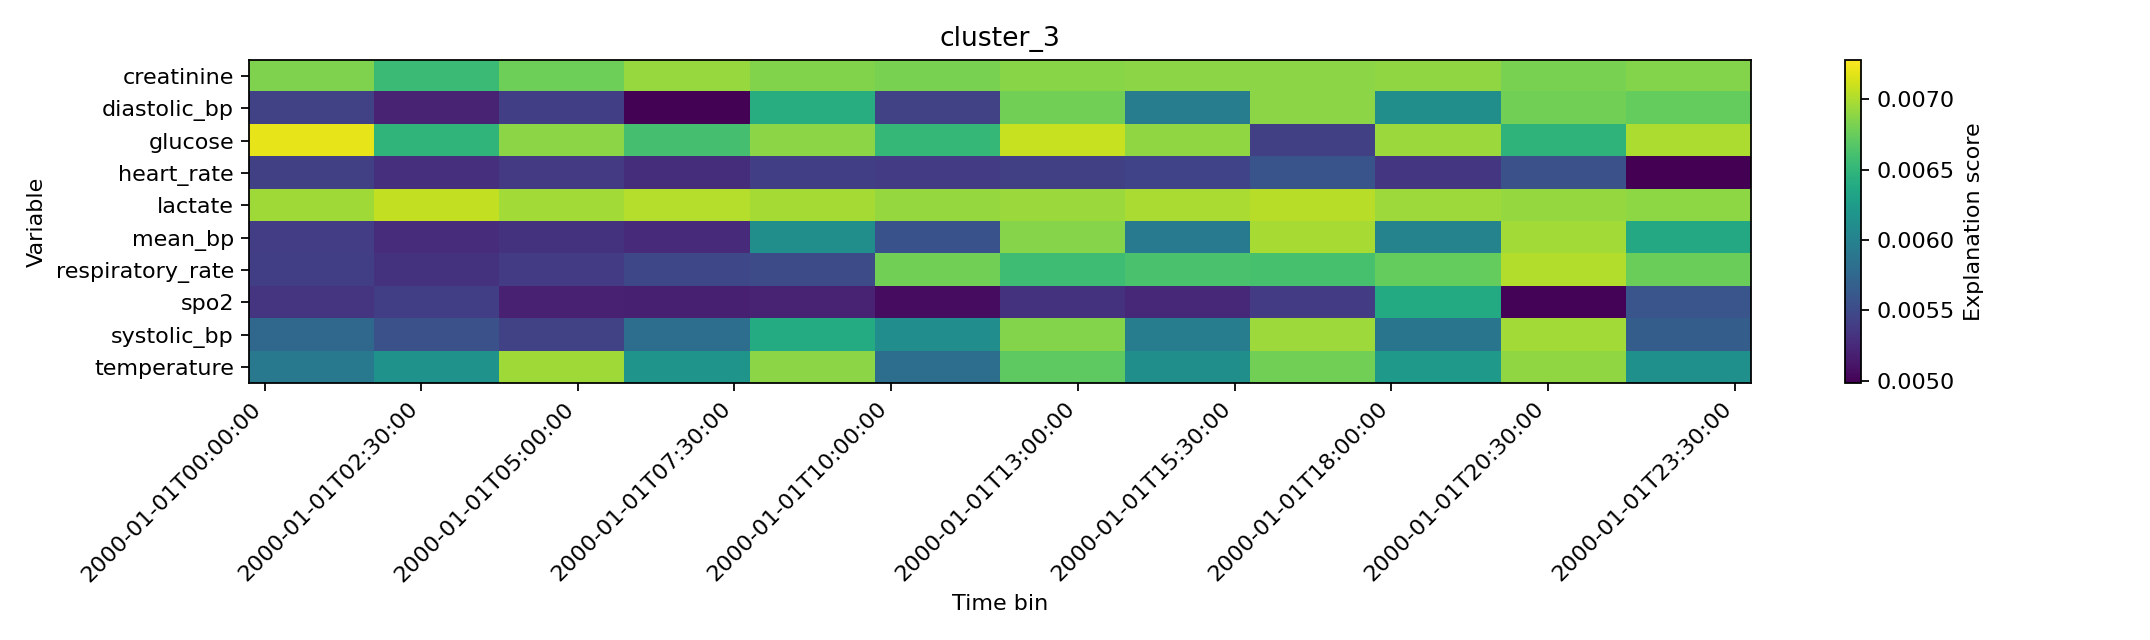

In [9]:
from IPython.display import Image, display

heatmap_dir = RUN_DIR / 'cluster_heatmaps' / 'test'
heatmaps = sorted(heatmap_dir.glob('*.png'))
print(f'Found {len(heatmaps)} cluster heatmaps in {heatmap_dir}')
for heatmap in heatmaps:
    print(heatmap.name)
    display(Image(filename=str(heatmap)))

## 7. Load The Saved Model Later

This cell demonstrates that the saved run is portable: it reloads `model.pt`, `binner.json`, and the saved test split, then evaluates again.

In [ ]:
from interpretable_ts_vit.io import load_model, load_split
from interpretable_ts_vit.training import evaluate_model

loaded_model = load_model(RUN_DIR)
test_dataset = load_split(RUN_DIR / 'test.npz')
loaded_metrics = evaluate_model(loaded_model, test_dataset, config.train)
print('Reloaded model test metrics:', loaded_metrics)